# Project 1

## Collect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable

   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

In [4]:
sdf=pd.read_sas("SMQ.xpt", format="xport")
sdf.head()

,SEQN,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMD070,SMD075,...,SMQ180,SMD190,SMQ200,SMD203,SMQ205,SMQ210,SMD220,SMQ230,SMD233,SMD235
0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
1,5.0,1.0,5.397605e-79,3.0,5.0,3.0,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,1.0,5.397605e-79,NaN,NaN,NaN
2,7.0,1.0,1.700000e+01,3.0,20.0,4.0,39.0,20.0,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
3,10.0,1.0,1.600000e+01,1.0,NaN,NaN,NaN,NaN,10.0,25.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
4,12.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN


In [5]:
new_df=pd.merge(df, sdf, on="SEQN", how="inner")
new_df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,SMQ180,SMD190,SMQ200,SMD203,SMQ205,SMQ210,SMD220,SMQ230,SMD233,SMD235
0,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
1,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,1.0,5.397605e-79,NaN,NaN,NaN
2,7.0,1.0,2.0,2.0,2.0,59.0,712.0,712.0,4.0,2.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
3,10.0,1.0,2.0,2.0,1.0,43.0,518.0,518.0,4.0,2.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
4,12.0,1.0,2.0,1.0,1.0,37.0,453.0,454.0,3.0,1.0,...,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN


## Data Cleaning

In [6]:
# do you smoke cigarettes data
# getting rid of refused and don't know values and missing
new_df["SMQ040"] = new_df["SMQ040"].replace({7: pd.NA, 9: pd.NA})
new_df["SMQ040"] = new_df["SMQ040"].replace(".", pd.NA)
# changing it so 1 is smoker and 0 is non-smoker
new_df["currentSmoker"] = new_df["SMQ040"].map({
    1: 1,
    2: 1,
    3: 0
})
# checking
new_df["currentSmoker"].value_counts(dropna=False)



currentSmoker
NaN    2581
0.0    1300
1.0     999
Name: count, dtype: int64

In [7]:
# average cigarettes smoked per day
# getting rid of refused and don't know values and missing
new_df["averageCigs"] = pd.to_numeric(new_df["SMD090"], errors="coerce")
new_df["averageCigs"] = new_df["averageCigs"].replace({777: pd.NA, 999: pd.NA})
new_df.loc[new_df["currentSmoker"] == 0, "averageCigs"] = 0
# checking
new_df["averageCigs"].describe()


count     2298
unique      33
top          0
freq      1300
Name: averageCigs, dtype: int64

In [8]:
# age started smoking cigarettes
# getting rid of refused and don't know values and missing
new_df["startSmokeAge"] = pd.to_numeric(new_df["SMD030"], errors="coerce")
new_df["startSmokeAge"] = new_df["startSmokeAge"].replace({777: pd.NA, 999: pd.NA})
# remove unrealistic ages
# remove unrealistic ages (should be at least 5)
new_df.loc[new_df["startSmokeAge"] < 5, "startSmokeAge"] = pd.NA
# set to NA for non-smokers
# new_df.loc[new_df["currentSmoker"] == 0, "startSmokeAge"] = np.nan
# checking
new_df.loc[new_df["currentSmoker"] == 1, "startSmokeAge"].describe()


count     968.0
unique     46.0
top        16.0
freq      123.0
Name: startSmokeAge, dtype: float64

In [9]:
# checking all 3 together
print(new_df[["currentSmoker", "averageCigs", "startSmokeAge"]].describe())
print(pd.crosstab(new_df["currentSmoker"], new_df["averageCigs"] == 0))

       currentSmoker
count    2299.000000
mean        0.434537
std         0.495804
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
averageCigs    False  True 
currentSmoker              
0.0                0   1300
1.0              999      0


## EDA

The variables we focused on were- 
Avg cigarettes per day over the past 30 days (SMD090)
Do you now smoke cigarettes (SMQ040)
Age started smoking cigarets regularly (SMD030)

In [17]:
new_df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,SMD203,SMQ205,SMQ210,SMD220,SMQ230,SMD233,SMD235,currentSmoker,averageCigs,startSmokeAge
0,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,1.0,2.0,2.0,1.0,49.0,597.0,597.0,3.0,1.0,...,NaN,NaN,1.0,5.397605e-79,NaN,NaN,NaN,0.0,0,<NA>
2,7.0,1.0,2.0,2.0,2.0,59.0,712.0,712.0,4.0,2.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,0.0,0,17.0
3,10.0,1.0,2.0,2.0,1.0,43.0,518.0,518.0,4.0,2.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0,10.0,16.0
4,12.0,1.0,2.0,1.0,1.0,37.0,453.0,454.0,3.0,1.0,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Start Smoking Age**

In [18]:
new_df['startSmokeAge'].head()

0     NaN
1    <NA>
2    17.0
3    16.0
4     NaN
Name: startSmokeAge, dtype: object

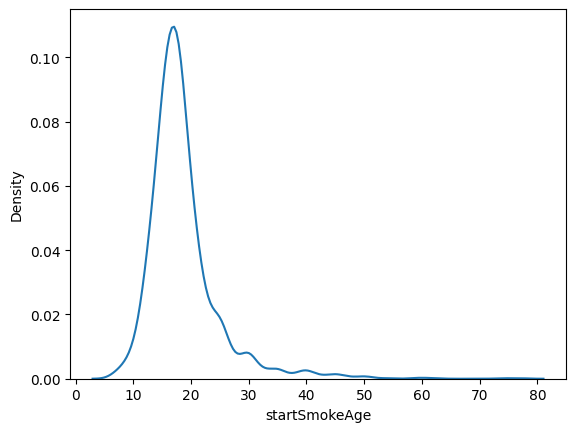

In [19]:
#kde plot of start smoke age
sns.kdeplot(new_df, x="startSmokeAge")
plt.show()

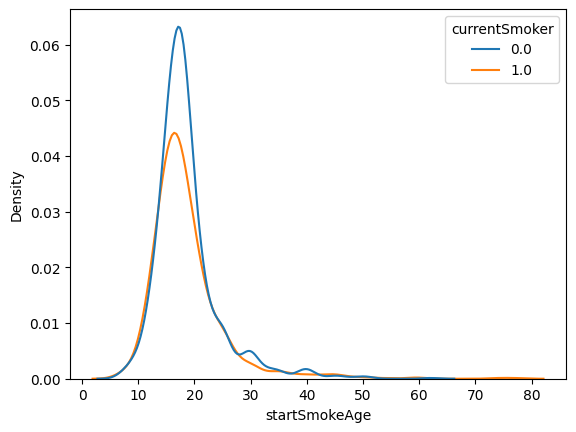

In [20]:
#kde plot of start smoke age and if someone is a current smoker
sns.kdeplot(new_df, x="startSmokeAge", hue="currentSmoker")
plt.show()

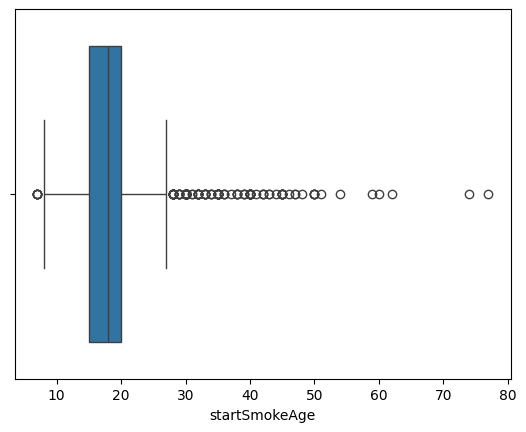

In [21]:
#looking for outliers
sns.boxplot(new_df, x=new_df["startSmokeAge"])
plt.show()

The startSmokeAge variable is mostly normally distributed, but is skewed slightly to the right. Both the current and not-current smokers have similar distributions. There tend to be way more upper outliers for both current smokers and non-smokers, further indicating that the data is skewed right. There are also more non-smokers than current smokers as seen in the second kde plot. 

**Average Cigarettes Per Day**

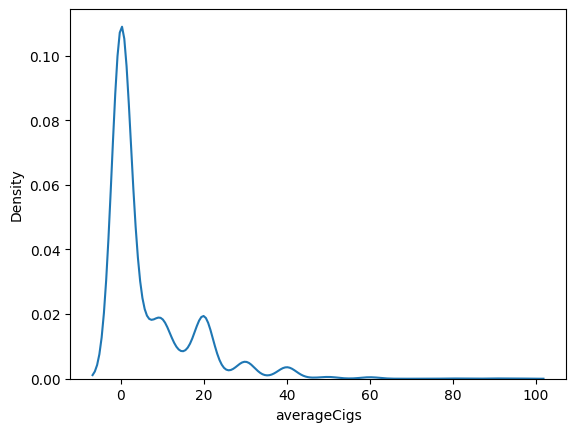

In [22]:
#kde plot of average cigarettes smoked per day
sns.kdeplot(new_df, x="averageCigs")
plt.show()

/var/folders/xw/862scxqj24x_pzb3r1wxwdq80000gn/T/ipykernel_49865/1751868653.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(new_df, x="averageCigs", hue="currentSmoker")


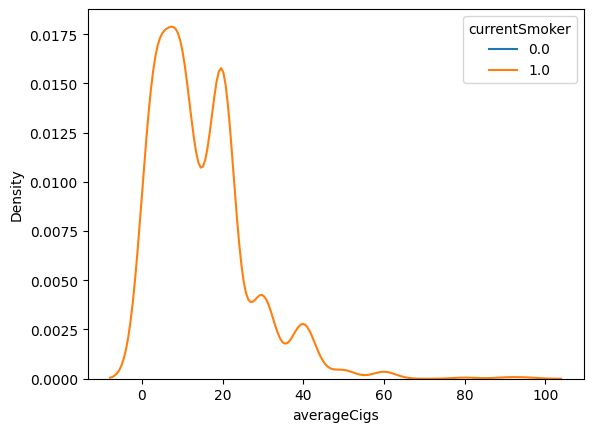

In [23]:
#average cigarettes smoked per day if someone is a current smoker (non-current smokers are all 0 so its is not shown on the graph)
sns.kdeplot(new_df, x="averageCigs", hue="currentSmoker")
plt.show()

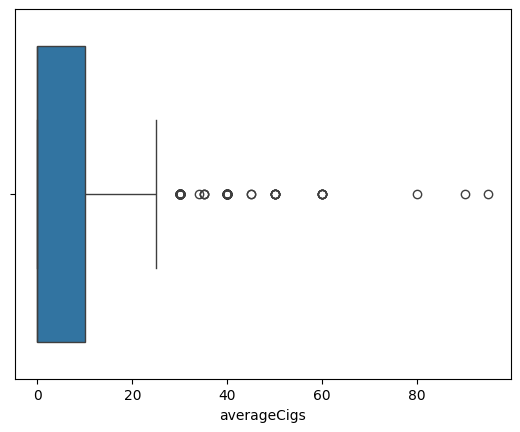

In [24]:
#looking for outliers
sns.boxplot(new_df, x=new_df["averageCigs"])
plt.show()

Because all of the non-smokers have an average of 0 cigarettes per day, the kde plot looks much different for both smokers and non-smokers than just smokers. However, both plots are skewed right. There are also a lot of upper outliers for this variable, but no lower outliers.

**Current Smoker**

In [25]:
new_df["currentSmoker"].value_counts()

currentSmoker
0.0    1300
1.0     999
Name: count, dtype: int64

There are currently 1300 current non-smokers and 999 current smokers in this data set.

**Comparing Variables**

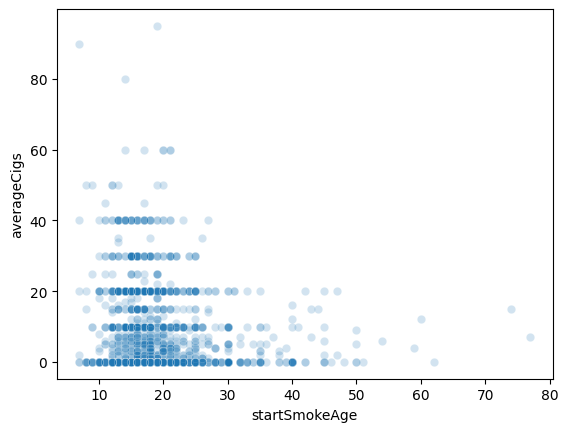

In [26]:
sns.scatterplot(data=new_df, x="startSmokeAge", y="averageCigs", alpha =.2)
plt.show()

There doesn't appear to be strong association between average cigarettes per day and the age when someone started smoking.  There is a slight negative association, in that those who started smoking earlier may tend to have more cigarettes per day than those who started smoking later, but many of these are outliers and are clustered together without an association. Because all of those who do not smoke have an average of 0 cigarettes per day, it does not make sense to add in the current smoker variable. 

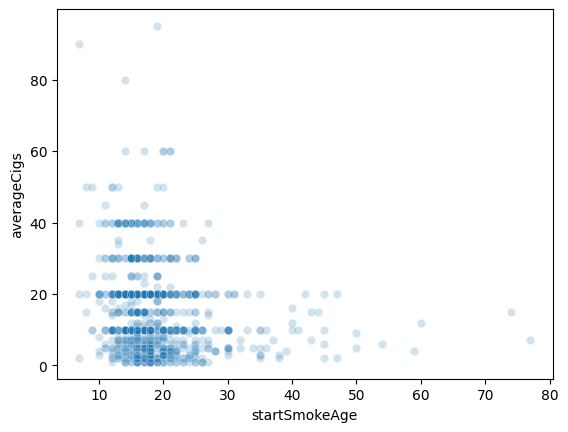

In [27]:
sns.scatterplot(data=new_df, x="startSmokeAge", y=new_df["averageCigs"][new_df["averageCigs"] != 0], alpha =.2)
plt.show()

**Looking at ELIGSTAT, MORTSTAT, PERMTH_INT, RIDAGEEX**

**ELIGSTAT**

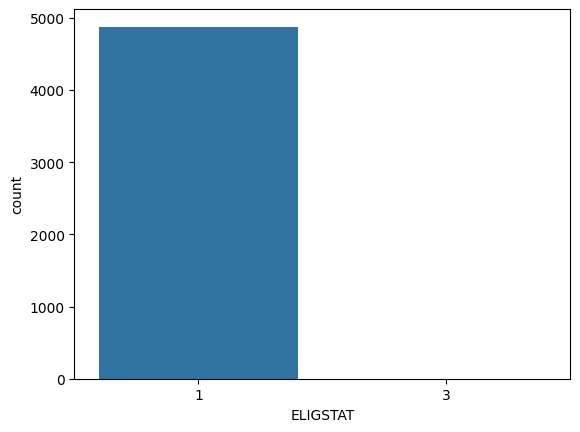

In [35]:
#countplot plot of average ELIGSTAT
sns.countplot(new_df, x="ELIGSTAT")
plt.show()

In [30]:
new_df["ELIGSTAT"].value_counts()

ELIGSTAT
1    4877
3       3
Name: count, dtype: int64

ELIGSTAT is a categorical variable that determines whether someone was eligible for mortality linkage. Most of the participants were eligible and only 3 were not because of insufficient identifying data. 

**MORTSTAT**

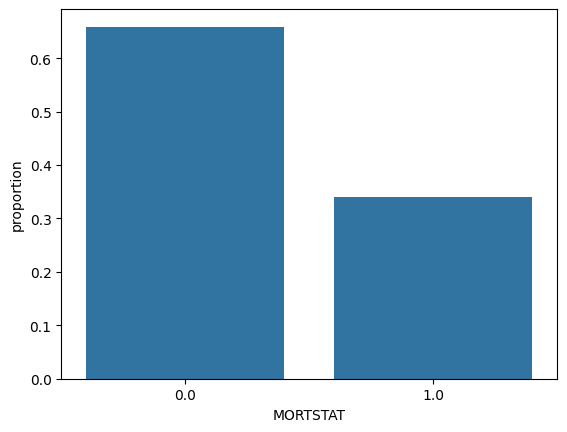

In [38]:
#countplot of average MORTSTAT
sns.countplot(new_df, x="MORTSTAT", stat="proportion")
plt.show()

MORTSTAT is another categorical variable, and it appears that .7 of those who were eligible with ELIGSTAT were assumed alive and around .3 were assumed deceased. 

**PERMTH_INT**

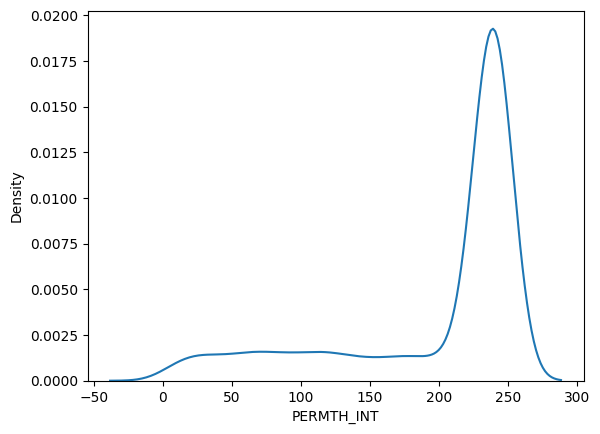

In [ ]:
#PERMTH_INT overall
sns.kdeplot(new_df, x="PERMTH_INT")
plt.show()

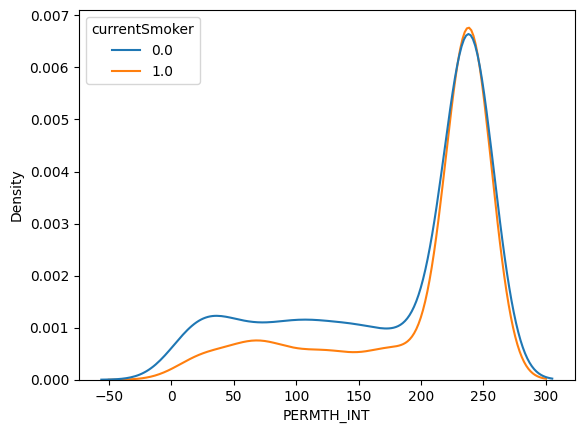

In [42]:
#PERMTH_INT if someone is a current smoker 
sns.kdeplot(new_df, x="PERMTH_INT", hue="currentSmoker")
plt.show()

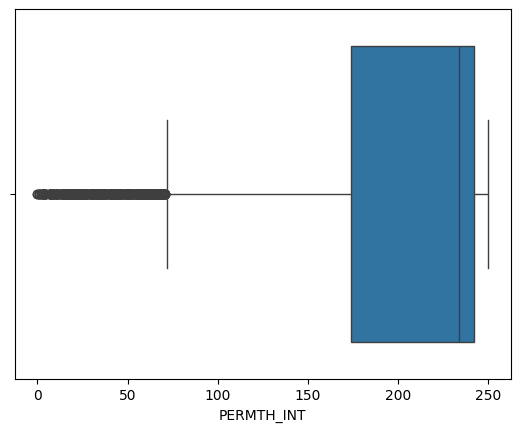

In [45]:
sns.boxplot(new_df, x="PERMTH_INT")
plt.show()

PERMTH_INT is very left-skewed and has many lower outliers.

**RIDAGEEX**

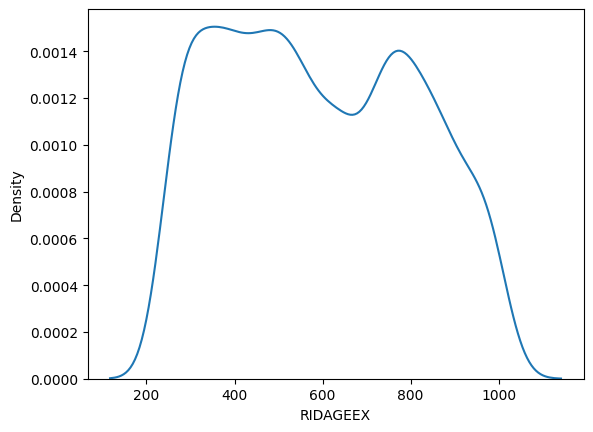

In [46]:
#RIDAGEEX overall
sns.kdeplot(new_df, x="RIDAGEEX")
plt.show()

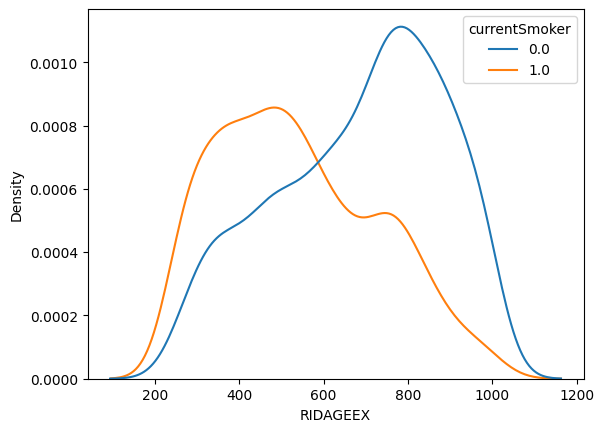

In [47]:
#RIDAGEEX if someone is a current smoker 
sns.kdeplot(new_df, x="RIDAGEEX", hue="currentSmoker")
plt.show()

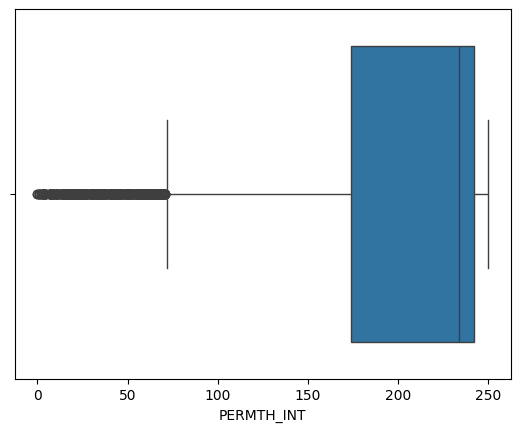

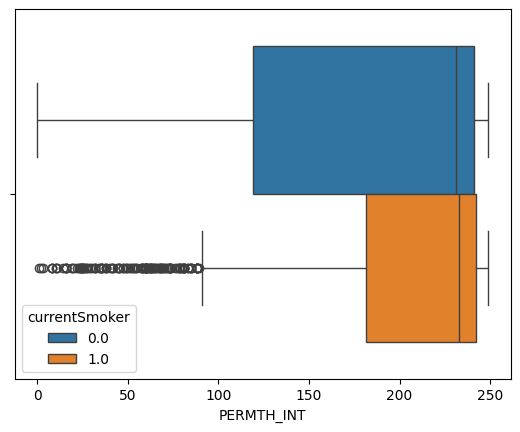

In [48]:
sns.boxplot(new_df, x="PERMTH_INT")
plt.show()

sns.boxplot(new_df, x="PERMTH_INT", hue="currentSmoker")
plt.show()

Overall, the data has many lower outliers and is left-skewed. Those who are current smokers have more lower outliers. Those who are current smokers have a peak for RIDAGEEX at a later age than those who are not current smokers. The overall data is also bimodal in the kde plot. 

**Comparing Variables**

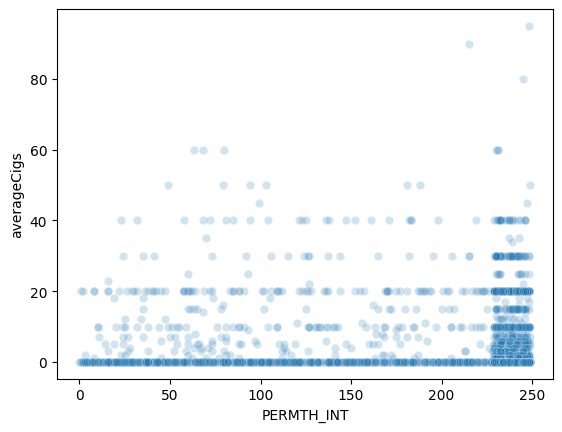

In [ ]:
#scatterplot of PERMTH_INT and average cigarettes smoked per day 
sns.scatterplot(data=new_df, x="PERMTH_INT", y="averageCigs", alpha =.2)
plt.show()

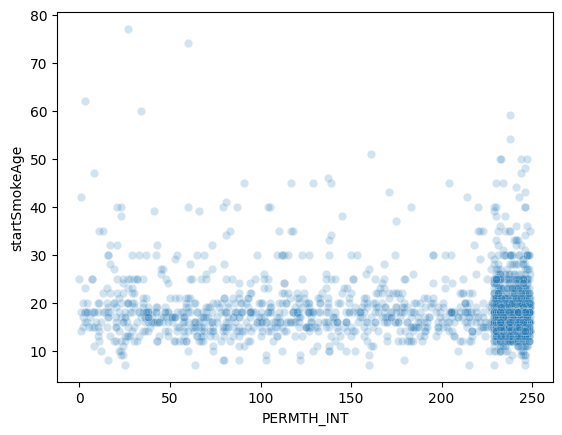

In [44]:
#scatterplot of PERMTH_INT and start smoke age
sns.scatterplot(data=new_df, x="PERMTH_INT", y="startSmokeAge", alpha =.2)
plt.show()

These graphs both largely follow the shape of the PERMTH_INT variable. 

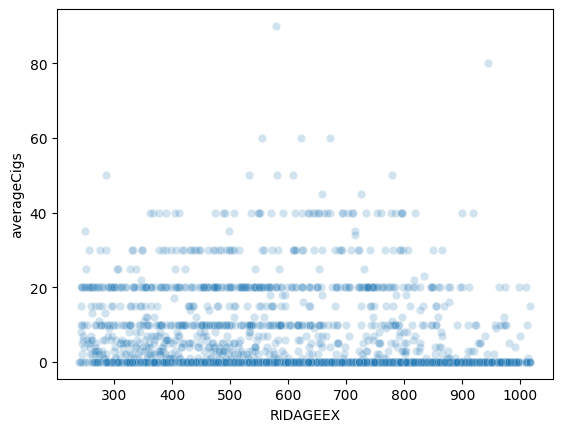

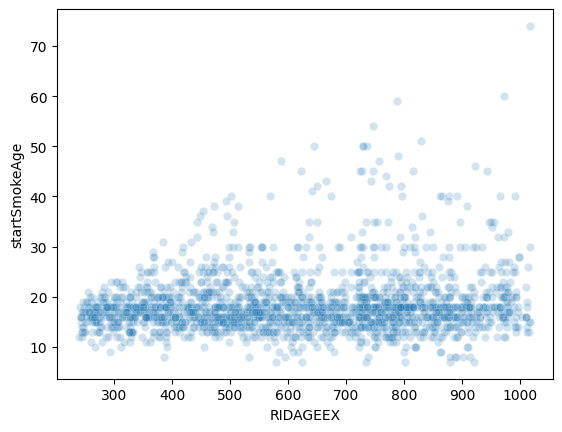

In [49]:
#scatterplot of RIDAGEEX and average cigarettes smoked per day 
sns.scatterplot(data=new_df, x="RIDAGEEX", y="averageCigs", alpha =.2)
plt.show()

#scatterplot of RIDAGEEX and start smoke age
sns.scatterplot(data=new_df, x="RIDAGEEX", y="startSmokeAge", alpha =.2)
plt.show()

Neither of these scatterplots show much association, with start smoking age and RIDAGEEX showing a very slight positive association, but not much. Otherwise, these scatterplots appear to be mostly evenly distributed of both start smoking age and average cigarettes for the RIDAGEEX variable. 

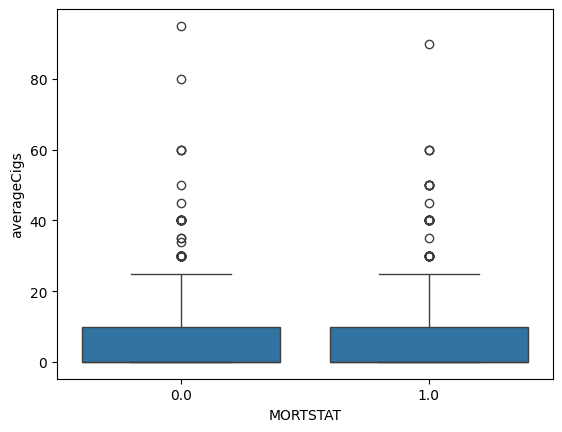

In [53]:
sns.boxplot(data=new_df, x="MORTSTAT", y="averageCigs")
plt.show()

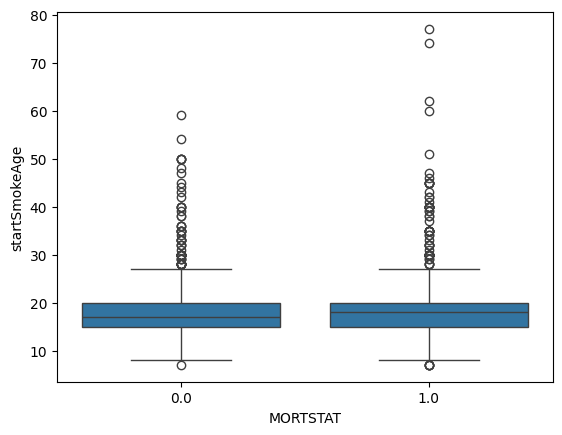

In [54]:
sns.boxplot(new_df, x="MORTSTAT", y="startSmokeAge")
plt.show()

Those who start smoking at a later age are more slightly likely to be alive than those who start smoking earlier. 

In [12]:
pd.crosstab(new_df["currentSmoker"], new_df["MORTSTAT"])

MORTSTAT,0.0,1.0
currentSmoker,,
0.0,697,601
1.0,672,327


The results of this are not what I anticipated. Those who are current smokers are less likely to be assumed deceased than not current smokers. 

Overall, all of the features are mostly normal, some having some skew or outliers, and appear that they could be used in a kNN classifier. 

## K Nearest Neighbor Classifier

In [46]:
# -----------------------------------------
# STEP 1: Select relevant variables
# -----------------------------------------

# Keep only mortality and smoking variables
df_model = new_df[[
    "MORTSTAT",        # Mortality outcome (0 = alive, 1 = deceased)
    "currentSmoker",   # Whether currently smokes
    "averageCigs",     # Average cigarettes per day
    "startSmokeAge"    # Age started smoking regularly
]]

# Remove rows with any missing values
df_model = df_model.dropna()

print("Shape after dropping missing values:", df_model.shape)

Shape after dropping missing values: (2132, 4)


In [48]:
# -----------------------------------------
# STEP 2: Define predictors (X) and target (y)
# -----------------------------------------

# X contains the smoking behavior predictors
X = df_model[["currentSmoker", "averageCigs", "startSmokeAge"]]

# y contains the mortality outcome
y = df_model["MORTSTAT"]

In [49]:
# -----------------------------------------
# STEP 3: Split into training and test sets
# -----------------------------------------

from sklearn.model_selection import train_test_split

# Split 70% training / 30% testing
# stratify=y ensures mortality proportions are preserved
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [50]:
# -----------------------------------------
# STEP 4: Standardize predictor variables
# -----------------------------------------

# kNN relies on distance calculations
# Standardizing ensures all variables are on the same scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

In [51]:
# -----------------------------------------
# STEP 5: Select optimal k
# -----------------------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 26)   # Try k values from 1 to 25
accuracies = []

# Loop over possible k values
for k in k_values:
    
    # Initialize kNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Fit model on training data
    knn.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = knn.predict(X_test_scaled)
    
    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Choose k with highest test accuracy
best_k = k_values[np.argmax(accuracies)]

print("Best k:", best_k)
print("Best test accuracy:", max(accuracies))

Best k: 4
Best test accuracy: 0.5859375


In [52]:
# -----------------------------------------
# STEP 6: Fit final model using best k
# -----------------------------------------

# Initialize model with optimal k
knn_final = KNeighborsClassifier(n_neighbors=best_k)

# Fit on training data
knn_final.fit(X_train_scaled, y_train)

# Generate predictions on test data
y_pred = knn_final.predict(X_test_scaled)

In [53]:
# -----------------------------------------
# STEP 7: Evaluate model performance
# -----------------------------------------

from sklearn.metrics import confusion_matrix, classification_report

# Overall accuracy
print("Final Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix shows correct/incorrect predictions
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Precision, recall, F1 score for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.5859375
Confusion Matrix:
 [[315  60]
 [205  60]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.61      0.84      0.70       375
         1.0       0.50      0.23      0.31       265

    accuracy                           0.59       640
   macro avg       0.55      0.53      0.51       640
weighted avg       0.56      0.59      0.54       640



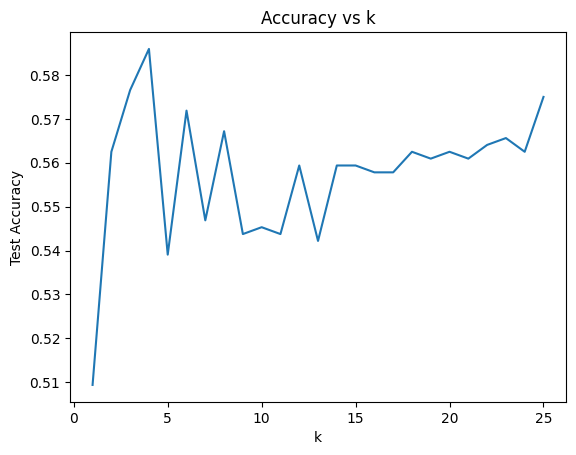

In [54]:
# print visual 
import matplotlib.pyplot as plt

plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()

The accuracy vs. k graph shows that test accuracy increases quickly at small values of k, peaks around k = 4, and then levels off as k becomes larger. This suggests that very small values of k slightly overfit, while larger values begin to smooth predictions too much and reduce performance. We selected k = 4 because it produced the highest test accuracy.

The final model achieved about 59% accuracy. The confusion matrix shows that the model predicts survival much better than death, correctly identifying most survivors but missing many mortality cases. This imbalance suggests that smoking behavior provides some predictive information, but it is not sufficient on its own to accurately classify mortality outcomes.